<a href="https://colab.research.google.com/github/aannddrree/disciplinaIA/blob/main/aula_pratica_tipos_de_aprendizado_python_for_dummies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula Prática de IA em Python

## Tipos de aprendizado:
- Supervisionado
- Não supervisionado
- Por reforço


## Antes de começar

Instalação de dependências

In [2]:
# Descomente a linha abaixo apenas se necessário:
!pip install scikit-learn matplotlib
print("Ambiente pronto! Se não houver erro nas próximas células, está tudo certo.")

Ambiente pronto! Se não houver erro nas próximas células, está tudo certo.


# 1. Aprendizado Supervisionado

### Ideia simples
No aprendizado supervisionado, a máquina aprende com **exemplos que já têm resposta**.

### Exemplo do dia a dia
- Horas de estudo -> nota
- Tamanho da casa -> preço
- Idade do carro -> valor de venda

Aqui vamos ensinar o computador a prever a **nota** de um aluno com base nas **horas de estudo**.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dados de treino
# X = horas de estudo
X = np.array([[1], [2], [3], [4], [5]])

# y = nota
y = np.array([2, 4, 6, 8, 10])

# Criando o modelo
modelo = LinearRegression()

# Treinando
modelo.fit(X, y)

# Fazendo uma previsão para 6 horas de estudo
horas_novas = np.array([[6]])
nota_prevista = modelo.predict(horas_novas)

print(f"Para 6 horas de estudo, a nota prevista é: {nota_prevista[0]:.2f}")

Para 6 horas de estudo, a nota prevista é: 12.00


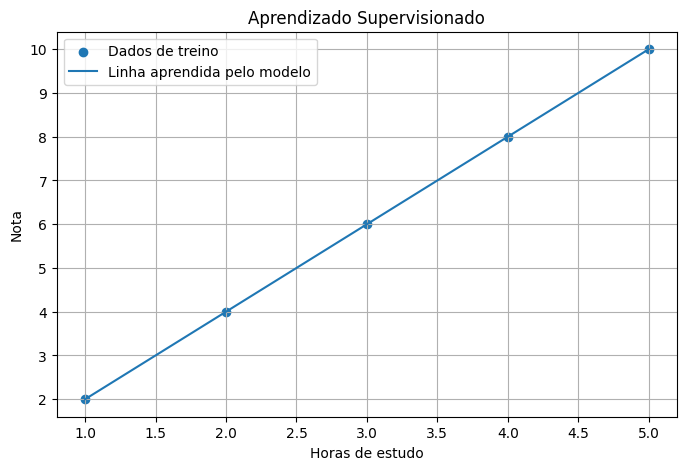

In [8]:
# Visualizando os dados e a reta aprendida pelo modelo

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados de treino")
plt.plot(X, modelo.predict(X), label="Linha aprendida pelo modelo")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.title("Aprendizado Supervisionado")
plt.legend()
plt.grid(True)
plt.show()

## Explicando de forma bem simples

O computador observou:

- 1 hora -> nota 2
- 2 horas -> nota 4
- 3 horas -> nota 6
- 4 horas -> nota 8
- 5 horas -> nota 10

Então ele percebeu um padrão e tentou continuar esse padrão.

---

## Atividade 1
Altere os valores de `X` e `y` e veja como a previsão muda.
Sugestão:
- 1 hora -> nota 1
- 2 horas -> nota 3
- 3 horas -> nota 5
- 4 horas -> nota 7
- 5 horas -> nota 9

# 2. Aprendizado Não Supervisionado

### Ideia simples
No aprendizado não supervisionado, a máquina recebe os dados **sem resposta pronta** e tenta encontrar padrões sozinha.

### Exemplo do dia a dia
- Separar clientes parecidos
- Descobrir grupos de músicas parecidas
- Identificar perfis semelhantes de consumo

Aqui vamos agrupar pessoas pela **altura**.

In [9]:
from sklearn.cluster import KMeans

# Dados de altura
dados = np.array([
    [150],
    [155],
    [160],
    [170],
    [175],
    [180]
])

# Criando o modelo com 2 grupos
modelo_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Treinando
modelo_kmeans.fit(dados)

# Mostrando os grupos encontrados
print("Rótulos dos grupos encontrados:")
print(modelo_kmeans.labels_)

print("\nCentros dos grupos:")
print(modelo_kmeans.cluster_centers_)

Rótulos dos grupos encontrados:
[0 0 0 1 1 1]

Centros dos grupos:
[[155.]
 [175.]]


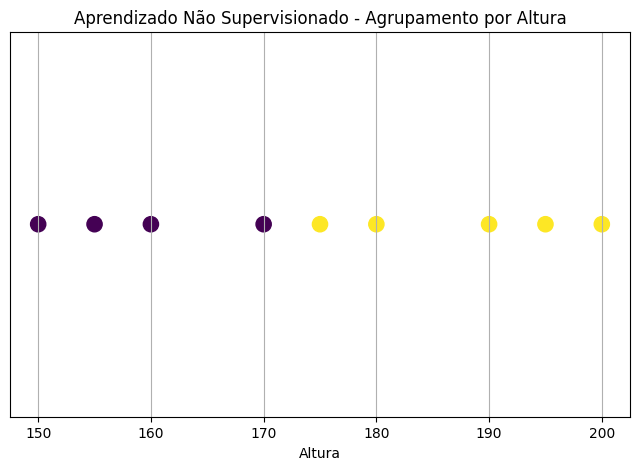

In [12]:
# Visualização dos grupos
plt.figure(figsize=(8, 5))
plt.scatter(dados[:, 0], [1]*len(dados), c=modelo_kmeans.labels_, s=120)
plt.xlabel("Altura")
plt.yticks([])
plt.title("Aprendizado Não Supervisionado - Agrupamento por Altura")
plt.grid(True)
plt.show()

## Explicando de forma bem simples

Aqui ninguém falou:
- quem é baixo
- quem é alto

O algoritmo olhou para os dados e criou grupos sozinho.

---

## Atividade 2
Adicione novas alturas, por exemplo:
- 190
- 195
- 200

Depois execute novamente e veja se os grupos mudam.

In [13]:
from sklearn.cluster import KMeans

# Dados de altura
dados = np.array([
    [150],
    [155],
    [160],
    [170],
    [175],
    [180],
    [190],
    [195],
    [200],
])

# Criando o modelo com 2 grupos
modelo_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Treinando
modelo_kmeans.fit(dados)

# Mostrando os grupos encontrados
print("Rótulos dos grupos encontrados:")
print(modelo_kmeans.labels_)

print("\nCentros dos grupos:")
print(modelo_kmeans.cluster_centers_)

Rótulos dos grupos encontrados:
[0 0 0 0 1 1 1 1 1]

Centros dos grupos:
[[158.75]
 [188.  ]]


# 3. Aprendizado por Reforço

### Ideia simples
No aprendizado por reforço, um agente aprende tentando ações e recebendo recompensa ou punição.

### Exemplo do dia a dia
- Um robô aprendendo a andar
- Um carro autônomo aprendendo a tomar decisões
- Um personagem de jogo aprendendo a vencer obstáculos

Aqui faremos uma simulação bem simples:
- o agente pode escolher **esquerda** ou **direita**
- quando escolhe **direita**, ele ganha ponto

In [15]:
import random

acoes = ["esquerda", "direita"]

# valor inicial de cada ação
valores = {
    "esquerda": 0,
    "direita": 0
}

for rodada in range(10):

    # escolhe ação com maior valor aprendido
    acao = max(valores, key=valores.get)

    # pequena chance de explorar
    if random.random() < 0.3:
        acao = random.choice(acoes)

    # recompensa do ambiente
    if acao == "direita":
        recompensa = 1
    else:
        recompensa = 0

    # atualizar aprendizado
    valores[acao] = valores[acao] + recompensa

    print(f"Rodada {rodada+1}: {acao} -> recompensa {recompensa}")

print("\nValores aprendidos:")
print(valores)

Rodada 1: esquerda -> recompensa 0
Rodada 2: esquerda -> recompensa 0
Rodada 3: esquerda -> recompensa 0
Rodada 4: esquerda -> recompensa 0
Rodada 5: esquerda -> recompensa 0
Rodada 6: direita -> recompensa 1
Rodada 7: direita -> recompensa 1
Rodada 8: direita -> recompensa 1
Rodada 9: direita -> recompensa 1
Rodada 10: esquerda -> recompensa 0

Valores aprendidos:
{'esquerda': 0, 'direita': 4}


## Explicando de forma bem simples

Com o tempo o agente percebe:

direita = recompensa
esquerda = nada

Então ele passa a escolher direita cada vez mais.

Agora sim existe:

✔ tentativa
✔ recompensa
✔ atualização
✔ melhoria da decisão

Reinforcement Learning é errar bastante até descobrir o que funciona melhor.

# 4. Comparação Final

| Tipo | Como aprende | Exemplo simples |
|---|---|---|
| Supervisionado | Aprende com exemplos e respostas | Prever nota |
| Não supervisionado | Encontra padrões sozinho | Agrupar alturas |
| Por reforço | Aprende com recompensa | Escolher ações |

# 5. Desafio Final para os alunos

Responda:

1. Qual tipo de aprendizado poderia ser usado para prever o preço de uma casa?
2. Qual tipo de aprendizado poderia ser usado para separar clientes parecidos?
3. Qual tipo de aprendizado poderia ser usado para treinar um robô a andar?
4. O que muda entre aprender com resposta pronta e aprender sem resposta pronta?

# 6. Mini exercício extra

Tente pensar em um exemplo do seu dia a dia para cada tipo:

- Supervisionado:
- Não supervisionado:
- Por reforço:

Escreva com suas próprias palavras.